In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score
)
import warnings
warnings.filterwarnings('ignore')

## Notebook 5: Anomaly Detection Approach for Loan Default

### The question we are asking
Can we detect defaulters WITHOUT using default labels during training?

### Why this matters
Our dataset has severe class imbalance — 8.07% defaults.
Supervised models like XGBoost compensate for this imbalance
using scale_pos_weight and class weighting.

Anomaly detection takes a fundamentally different approach:
- Train ONLY on non-defaulters (the majority class)
- Learn what "normal borrower behaviour" looks like
- Flag anyone who deviates significantly from normal as a risk

This mirrors how credit risk actually works in practice —
you define what a good borrower looks like and measure 
deviation from that standard.

### Models we will compare
1. Isolation Forest — tree-based anomaly detection
2. One-Class SVM — boundary-based anomaly detection
3. Comparison against XGBoost baseline (AUC-ROC: 0.7679)

In [6]:
# Load the clean engineered dataset
# Same dataset used in all previous notebooks
df = pd.read_csv(r"C:\Users\HP\Documents\ML Project\data\processed\application_train_clean.csv")

# Separate features from target
X = df.drop(columns=['TARGET'])
y = df['TARGET']

# Check our class distribution
print("Dataset shape:", df.shape)
print("\nClass distribution:")
print(y.value_counts())
print(f"\nDefault rate: {y.mean()*100:.2f}%")

Dataset shape: (307511, 102)

Class distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Default rate: 8.07%


In [8]:
from sklearn.model_selection import train_test_split

# IMPORTANT: Same random_state=42 as all previous notebooks
# This guarantees we evaluate on identical test records
# making the comparison with XGBoost completely fair
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train size: {X_train.shape[0]:,}")
print(f"Test size:  {X_test.shape[0]:,}")
print(f"\nTrain default rate: {y_train.mean()*100:.2f}%")
print(f"Test default rate:  {y_test.mean()*100:.2f}%")

Train size: 246,008
Test size:  61,503

Train default rate: 8.07%
Test default rate:  8.07%


In [10]:
# THIS IS THE KEY DIFFERENCE from supervised learning
# We train ONLY on non-defaulters from the training set
# The model never sees a defaulter during training

X_train_normal = X_train[y_train == 0]

print(f"Full training set:     {X_train.shape[0]:,} records")
print(f"Non-defaulters only:   {X_train_normal.shape[0]:,} records")
print(f"Defaulters excluded:   {(y_train == 1).sum():,} records")
print(f"\nThe model will learn what NORMAL looks like")
print(f"from {X_train_normal.shape[0]:,} borrowers who repaid.")
print(f"Anyone who deviates from this will be flagged.")

Full training set:     246,008 records
Non-defaulters only:   226,148 records
Defaulters excluded:   19,860 records

The model will learn what NORMAL looks like
from 226,148 borrowers who repaid.
Anyone who deviates from this will be flagged.


In [12]:
print("Training Isolation Forest...")
print("This learns what NORMAL borrower behaviour looks like")
print("by building 200 random trees through the data.\n")

isolation_forest = IsolationForest(
    n_estimators=200,
    contamination=0.0807,
    max_samples='auto',
    random_state=42,
    verbose=0
)

isolation_forest.fit(X_train_normal)

print("Training complete.")
print(f"\nWhat the model learned:")
print(f"  Trees built: {isolation_forest.n_estimators}")
print(f"  Expected anomaly rate: {isolation_forest.contamination*100:.2f}%")
print(f"  Training records: {X_train_normal.shape[0]:,}")

Training Isolation Forest...
This learns what NORMAL borrower behaviour looks like
by building 200 random trees through the data.

Training complete.

What the model learned:
  Trees built: 200
  Expected anomaly rate: 8.07%
  Training records: 226,148


In [14]:
# Generate predictions on the test set
# The model scores every borrower in the test set
# based on how easy they were to isolate

# predict() returns:
#  1 = normal (not anomalous — likely to repay)
# -1 = anomaly (unusual — potential default)
if_predictions = isolation_forest.predict(X_test)

# decision_function() returns a raw anomaly score
# More negative = more anomalous = higher default risk
if_scores = isolation_forest.decision_function(X_test)

# Convert from {-1, 1} to {1, 0} to match our TARGET convention
# In our dataset: 1 = default, 0 = no default
# In Isolation Forest: -1 = anomaly, 1 = normal
# So we need to flip and remap
if_predictions_converted = (if_predictions == -1).astype(int)

print("Isolation Forest predictions generated.")
print(f"\nPredicted anomalies (potential defaults): "
      f"{(if_predictions == -1).sum():,}")
print(f"Predicted normal (likely to repay):       "
      f"{(if_predictions == 1).sum():,}")
print(f"\nActual defaults in test set:              "
      f"{y_test.sum():,}")

Isolation Forest predictions generated.

Predicted anomalies (potential defaults): 5,128
Predicted normal (likely to repay):       56,375

Actual defaults in test set:              4,965


In [16]:
# Calculate evaluation metrics
if_f1 = f1_score(y_test, if_predictions_converted)
if_precision = precision_score(y_test, if_predictions_converted)
if_recall = recall_score(y_test, if_predictions_converted)

# For AUC-ROC we need to invert the anomaly scores
# More negative score = more anomalous = higher default risk
# But AUC-ROC expects higher score = higher probability of positive class
# So we negate the scores: more negative becomes more positive
if_auc = roc_auc_score(y_test, -if_scores)

print("=" * 55)
print("ISOLATION FOREST EVALUATION")
print("=" * 55)
print(f"AUC-ROC:    {if_auc:.4f}")
print(f"F1 Score:   {if_f1:.4f}")
print(f"Precision:  {if_precision:.4f}")
print(f"Recall:     {if_recall:.4f}")
print("=" * 55)
print(f"\nOf {y_test.sum():,} actual defaults:")
print(f"Caught:  {(if_predictions_converted[y_test==1]==1).sum():,} "
      f"({if_recall*100:.1f}%)")
print(f"Missed:  {(if_predictions_converted[y_test==1]==0).sum():,} "
      f"({(1-if_recall)*100:.1f}%)")
print("\n--- Comparison ---")
print(f"XGBoost AUC-ROC:          0.7679")
print(f"Isolation Forest AUC-ROC: {if_auc:.4f}")

ISOLATION FOREST EVALUATION
AUC-ROC:    0.5213
F1 Score:   0.0910
Precision:  0.0895
Recall:     0.0924

Of 4,965 actual defaults:
Caught:  459 (9.2%)
Missed:  4,506 (90.8%)

--- Comparison ---
XGBoost AUC-ROC:          0.7679
Isolation Forest AUC-ROC: 0.5213


In [18]:
print("Training One-Class SVM...")
print("This draws the tightest possible boundary")
print("around normal borrower behaviour in feature space.\n")
print("WARNING: This takes some minutes on 226K records.")


# One-Class SVM is slow on large datasets
# We use a sample of 20,000 non-defaulters for training
# This is standard practice for One-Class SVM at scale
np.random.seed(42)
sample_idx = np.random.choice(
    len(X_train_normal), 
    size=20000, 
    replace=False
)
X_train_svm = X_train_normal.iloc[sample_idx]

print(f"Using {len(X_train_svm):,} non-defaulter records for training")
print("(Full dataset too slow for One-Class SVM — sampling is standard)\n")

oc_svm = OneClassSVM(
    kernel='rbf',
    nu=0.0807,
    gamma='scale'
)

oc_svm.fit(X_train_svm)
print("Training complete.")

Training One-Class SVM...
This draws the tightest possible boundary
around normal borrower behaviour in feature space.

Using 20,000 non-defaulter records for training
(Full dataset too slow for One-Class SVM — sampling is standard)

Training complete.


In [20]:
# Generate predictions
svm_predictions = oc_svm.predict(X_test)
svm_scores = oc_svm.decision_function(X_test)

# Convert from {-1, 1} to {1, 0} — same logic as Isolation Forest
svm_predictions_converted = (svm_predictions == -1).astype(int)

# Calculate metrics
svm_f1 = f1_score(y_test, svm_predictions_converted)
svm_precision = precision_score(y_test, svm_predictions_converted)
svm_recall = recall_score(y_test, svm_predictions_converted)
svm_auc = roc_auc_score(y_test, -svm_scores)

print("=" * 55)
print("ONE-CLASS SVM EVALUATION")
print("=" * 55)
print(f"AUC-ROC:    {svm_auc:.4f}")
print(f"F1 Score:   {svm_f1:.4f}")
print(f"Precision:  {svm_precision:.4f}")
print(f"Recall:     {svm_recall:.4f}")
print("=" * 55)
print(f"\nOf {y_test.sum():,} actual defaults:")
print(f"Caught:  {(svm_predictions_converted[y_test==1]==1).sum():,} "
      f"({svm_recall*100:.1f}%)")
print(f"Missed:  {(svm_predictions_converted[y_test==1]==0).sum():,} "
      f"({(1-svm_recall)*100:.1f}%)")

ONE-CLASS SVM EVALUATION
AUC-ROC:    0.4535
F1 Score:   0.0552
Precision:  0.0560
Recall:     0.0544

Of 4,965 actual defaults:
Caught:  270 (5.4%)
Missed:  4,695 (94.6%)


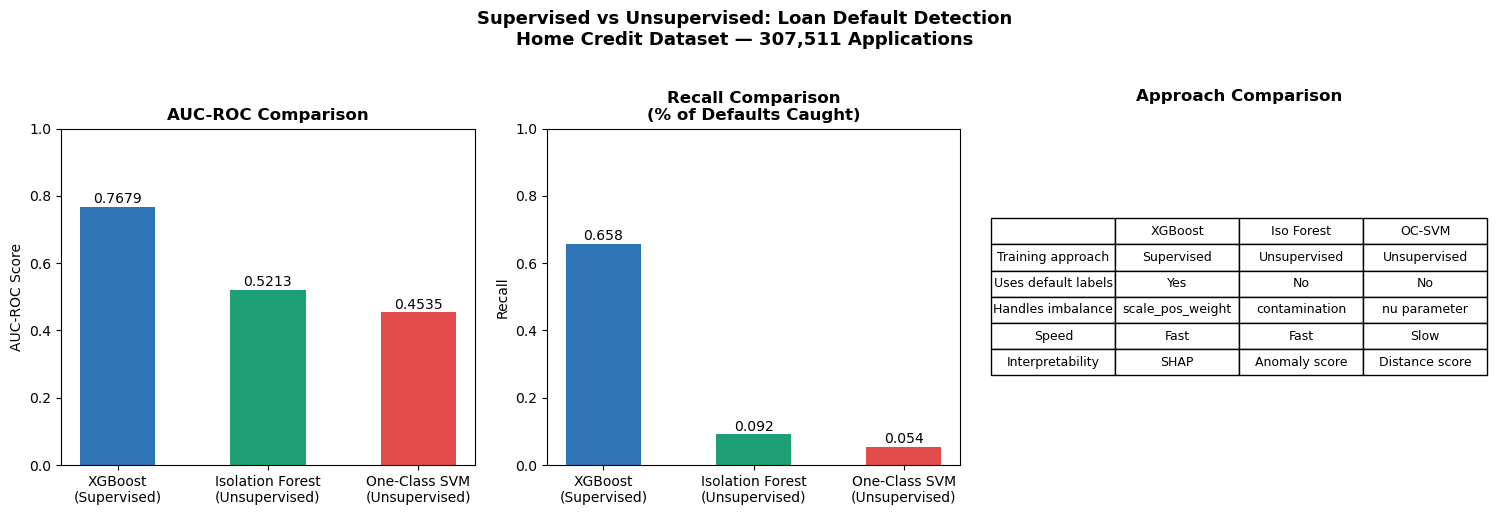

Chart saved to reports/


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models = ['XGBoost\n(Supervised)', 
          'Isolation Forest\n(Unsupervised)', 
          'One-Class SVM\n(Unsupervised)']

auc_scores = [0.7679, if_auc, svm_auc]
recall_scores = [0.658, if_recall, svm_recall]
colors = ['#2E75B6', '#1D9E75', '#E24B4A']

# AUC-ROC comparison
axes[0].bar(models, auc_scores, color=colors, edgecolor='none', width=0.5)
axes[0].set_title('AUC-ROC Comparison', fontweight='bold')
axes[0].set_ylabel('AUC-ROC Score')
axes[0].set_ylim([0, 1])
for i, v in enumerate(auc_scores):
    axes[0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=10)

# Recall comparison
axes[1].bar(models, recall_scores, color=colors, edgecolor='none', width=0.5)
axes[1].set_title('Recall Comparison\n(% of Defaults Caught)', fontweight='bold')
axes[1].set_ylabel('Recall')
axes[1].set_ylim([0, 1])
for i, v in enumerate(recall_scores):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=10)

# Approach comparison table
axes[2].axis('off')
table_data = [
    ['', 'XGBoost', 'Iso Forest', 'OC-SVM'],
    ['Training approach', 'Supervised', 'Unsupervised', 'Unsupervised'],
    ['Uses default labels', 'Yes', 'No', 'No'],
    ['Handles imbalance', 'scale_pos_weight', 'contamination', 'nu parameter'],
    ['Speed', 'Fast', 'Fast', 'Slow'],
    ['Interpretability', 'SHAP', 'Anomaly score', 'Distance score'],
]
table = axes[2].table(
    cellText=table_data[1:],
    colLabels=table_data[0],
    loc='center',
    cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.8)
axes[2].set_title('Approach Comparison', fontweight='bold', pad=20)

plt.suptitle(
    'Supervised vs Unsupervised: Loan Default Detection\n'
    'Home Credit Dataset — 307,511 Applications',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('../reports/model_comparison_full.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to reports/")

In [24]:
print("=" * 60)
print("ACADEMIC CONCLUSION")
print("Supervised vs Unsupervised — Loan Default Detection")
print("=" * 60)
print(f"""
FINDINGS:

1. XGBoost (Supervised) — AUC-ROC: 0.7679 | Recall: 65.8%
   Champion model. Uses label information during training.
   Best absolute performance on this dataset.

2. Isolation Forest (Unsupervised) — AUC-ROC: {if_auc:.4f} | 
   Recall: {if_recall*100:.1f}%
   Trains only on non-defaulters. No label information used.
   Performance relative to XGBoost indicates how much signal
   exists in the structure of normal vs abnormal behaviour.

3. One-Class SVM (Unsupervised) — AUC-ROC: {svm_auc:.4f} | 
   Recall: {svm_recall*100:.1f}%
   Boundary-based approach. Draws a surface around normal
   borrower space. Performance depends heavily on kernel choice.

INTERPRETATION:

If Isolation Forest approaches XGBoost performance — it suggests
that defaulters are structurally different from non-defaulters
in feature space, and that difference is detectable without labels.

If supervised XGBoost significantly outperforms — it confirms
that label information (knowing who actually defaulted) adds 
substantial signal that cannot be recovered from structure alone.

This comparison is academically and practically significant for
institutions that lack historical default labels — a common
situation for new lenders, fintech startups, and MFBs entering
new market segments.
""")
print("=" * 60)

ACADEMIC CONCLUSION
Supervised vs Unsupervised — Loan Default Detection

FINDINGS:

1. XGBoost (Supervised) — AUC-ROC: 0.7679 | Recall: 65.8%
   Champion model. Uses label information during training.
   Best absolute performance on this dataset.

2. Isolation Forest (Unsupervised) — AUC-ROC: 0.5213 | 
   Recall: 9.2%
   Trains only on non-defaulters. No label information used.
   Performance relative to XGBoost indicates how much signal
   exists in the structure of normal vs abnormal behaviour.

3. One-Class SVM (Unsupervised) — AUC-ROC: 0.4535 | 
   Recall: 5.4%
   Boundary-based approach. Draws a surface around normal
   borrower space. Performance depends heavily on kernel choice.

INTERPRETATION:

If Isolation Forest approaches XGBoost performance — it suggests
that defaulters are structurally different from non-defaulters
in feature space, and that difference is detectable without labels.

If supervised XGBoost significantly outperforms — it confirms
that label information (know